# NB04b — Consumer Statistics: what people buy

**Signal/Pulse · Validation layer · Public**

NB04 reads what consumers *say* (review text). This notebook reads what they
*buy*, from official statistics, and asks whether the two agree.

Every finding in NB05–NB07 rests on Google Trends and platform data. Both measure
**attention**. Neither measures volume or money. METHODOLOGY caveat 12 names this
as the open extension; this notebook closes the first half of it.

**Source:** 経済産業省生産動態統計調査 化学工業統計編「11. 化粧品」 — monthly, a
基幹統計, covering production, shipments and stock by product line.

**Run order:** NB04 → **NB04b** → NB05 → NB06 → NB07 (synthesis consumes this).

---

## 0. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.schema import get_connection
from src.viz import apply_style, fig_ax, tight

apply_style()
pd.set_option('display.width', 200)

ASSETS = '../dashboard/assets'
C_ATT  = '#4A90B8'   # attention
C_VAL  = '#C4627A'   # value shipped
print('ready')

Font: Hiragino Sans ✓


ready


---
## 1. Resolving the source

Two traps sit in front of this series, both recorded in the
`skincare-beauty-market` skill:

1. **工業統計調査 is not this series.** It was discontinued and folded into
   経済構造実態調査, which is annual and structured by establishment. The monthly
   product series is 生産動態統計.
2. **`statsDataId` is not stable.** The identifier commonly cited for this table
   resolves to a *single month* of 2010. The current series is published as one
   時系列表 per year, under IDs that changed at the 2021 survey revision.

`build_estat_shipments.py` resolves each year's table from `getStatsList` rather
than trusting a cached ID, then normalises two different table layouts into one
tidy frame. The cell below shows what it resolved.

In [2]:
import build_estat_shipments as bes   # noqa: E402

print('statsDataId per survey year (2019-2024 confirmed 2026-09-06, 2025 on 2026-09-16):')
for yr, sid in bes.TABLES.items():
    print(f'  {yr}: {sid}')
print(f'''
Months after the last annual table come from the newest monthly 確報 workbook,
so shipments reach mid-2026. Annual figures below use complete years only.''')

statsDataId per survey year (2019-2024 confirmed 2026-09-06, 2025 on 2026-09-16):
  2019: 0003416134
  2020: 0003437034
  2021: 0004001069
  2022: 0004014489
  2023: 0004019835
  2024: 0004032992
  2025: 0004061875

Months after the last annual table come from the newest monthly 確報 workbook,
so shipments reach mid-2026. Annual figures below use complete years only.


---
## 2. Load

`estat_meti_cosmetics.csv` is written by `build_estat_shipments.py`. It is
committed, so this notebook runs from a clone without an e-Stat key; re-run the
builder (with `ESTAT_APP_ID` set) to refresh it.

In [3]:
df = pd.read_csv(f'{ASSETS}/estat_meti_cosmetics.csv')
print(f'{len(df):,} rows | {df.item.nunique()} items | years {df.year.min()}–{df.year.max()}')
print(f'measures: {sorted(df.measure.unique())}')
print(f'\nunit per measure:')
print(df.groupby('measure')['unit'].unique().to_string())
df.head(3)

24,150 rows | 38 items | years 2015–2026
measures: ['出荷その他', '受入', '月末在庫', '生産', '販売個数', '販売数量', '販売金額']

unit per measure:
measure
出荷その他    [kg]
受入       [kg]
月末在庫     [kg]
生産       [kg]
販売個数     [十個]
販売数量     [kg]
販売金額     [千円]


,year,month,item,measure,unit,value,source_table_year,edition
0,2015,0,おしろい,出荷その他,kg,4176.0,2019,時系列表
1,2016,0,おしろい,出荷その他,kg,3983.0,2020,時系列表
2,2017,0,おしろい,出荷その他,kg,7034.0,2021,時系列表


### 2.1 Validation

Two checks before using any of it: are all twelve months present for the lines we
care about, and does the published annual row equal the sum of its months?

The second check matters because later tables restate earlier years. Where the
two disagree, the sum of months is used throughout — one vintage per year, and it
also covers 2024 and 2025, which have no annual row. A year still in progress
(2026) is left out of the annual table.

In [4]:
KEY = ['美容液','化粧水','乳液','モイスチャークリーム','洗顔クリーム・フォーム','パック',
       'ファンデーション','口紅','アイメークアップ','日やけ止め及び日やけ用化粧品']
val = df[df.measure == '販売金額']

months = val[(val.month > 0) & (val.item.isin(KEY))].groupby(['item','year']).size().unstack(fill_value=0)
print('months present per item-year (want 12 everywhere):')
print(months.to_string())

ann = val[val.month == 0].set_index(['year','item'])['value']
mon = val[val.month > 0].groupby(['year','item'])['value'].sum()
gap = pd.concat([ann.rename('annual_row'), mon.rename('sum_months')], axis=1).dropna()
gap['gap_%'] = (100 * (gap.sum_months - gap.annual_row) / gap.annual_row)
print(f'\nannual row vs sum of months — median |gap| {gap["gap_%"].abs().median():.2f}%, '
      f'max {gap["gap_%"].abs().max():.1f}%')
print('(the large ones are restatements between table vintages, not missing data)')

months present per item-year (want 12 everywhere):
year            2019  2020  2021  2022  2023  2024  2025  2026
item                                                          
アイメークアップ          12    12    12    12    12    12    12     7
パック               12    12    12    12    12    12    12     7
ファンデーション          12    12    12    12    12    12    12     7
モイスチャークリーム        12    12    12    12    12    12    12     7
乳液                12    12    12    12    12    12    12     7
化粧水               12    12    12    12    12    12    12     7
口紅                12    12    12    12    12    12    12     7
日やけ止め及び日やけ用化粧品    12    12    12    12    12    12    12     7
洗顔クリーム・フォーム       12    12    12    12    12    12    12     7
美容液               12    12    12    12    12    12    12     7

annual row vs sum of months — median |gap| 0.00%, max 16.5%
(the large ones are restatements between table vintages, not missing data)


In [5]:
# One vintage per year: sum the months. Complete years only — the 確報 months of
# a year in progress would read as a collapse if summed as a year.
n_months = val[val.month > 0].groupby('year')['month'].nunique()
FULL = n_months[n_months == 12].index
meti = (val[(val.month > 0) & val.year.isin(FULL)]
        .groupby(['year','item'])['value'].sum().unstack() / 1e5)  # 千円 -> 億円
LEAF = [c for c in meti.columns if not c.endswith('計')]
print('annual shipped value, 億円')
meti[KEY].round(0)

annual shipped value, 億円


item,美容液,化粧水,乳液,モイスチャークリーム,洗顔クリーム・フォーム,パック,ファンデーション,口紅,アイメークアップ,日やけ止め及び日やけ用化粧品
year,,,,,,,,,,
2019,1960.0,2285.0,976.0,772.0,810.0,372.0,1431.0,497.0,481.0,671.0
2020,1877.0,2030.0,822.0,603.0,697.0,266.0,880.0,222.0,332.0,538.0
2021,1512.0,1845.0,709.0,707.0,713.0,225.0,752.0,128.0,323.0,500.0
2022,995.0,1178.0,518.0,711.0,773.0,181.0,751.0,191.0,358.0,494.0
2023,1053.0,1091.0,533.0,678.0,751.0,183.0,816.0,270.0,369.0,632.0
2024,1197.0,1243.0,577.0,661.0,729.0,207.0,836.0,290.0,364.0,658.0
2025,1219.0,1204.0,615.0,692.0,793.0,221.0,861.0,277.0,354.0,652.0


---
## 3. Attention versus shipped value

Trends terms are matched to METI product lines. 「アイシャドウ」 maps to
アイメークアップ, which is broader than eyeshadow alone — the only makeup-eye line
the statistics carry.

In [6]:
# Attention comes from the same asset the dashboard reads, so the notebook and
# the page cannot drift apart. build_attention_annual.py derives the year from
# week_start rather than trusting trends_weekly.week_year, which labels January
# of 2021, 2022 and 2023 as the previous year and leaves 2020 with 13 months.
trend = (pd.read_csv(f'{ASSETS}/nb04b_attention_annual.csv')
         .pivot(index='year', columns='term', values='interest'))

PAIRS = [('美容液','美容液'), ('化粧水','化粧水'), ('乳液','乳液'),
         ('ファンデーション','ファンデーション'), ('口紅','口紅'), ('アイシャドウ','アイメークアップ')]
BREAK = 2022                       # located from the data in section 4b below
Y0, Y1 = 2019, int(meti.index.max())      # last complete year
REGIMES = [('before', Y0, BREAK - 1), ('after', BREAK, Y1)]

def deltas(y0, y1):
    out = []
    for t_term, m_item in PAIRS:
        t0, t1 = trend.loc[y0, t_term], trend.loc[y1, t_term]
        v0, v1 = meti.loc[y0, m_item], meti.loc[y1, m_item]
        out.append({'category': t_term,
                    'attention Δ%': round(100*(t1-t0)/t0),
                    'value Δ%': round(100*(v1-v0)/v0),
                    'same sign': 'yes' if (t1>t0) == (v1>v0) else 'NO'})
    return pd.DataFrame(out).set_index('category')

comp = pd.concat({f'{lab} {y0}→{y1}': deltas(y0, y1) for lab, y0, y1 in REGIMES}, axis=1)
# The full window is shown too — but only to be compared against the halves, not
# to be quoted. Section 4b is why.
comp_span = deltas(Y0, Y1)
print('Measured inside each regime:')
print(comp.to_string())
print(f'\nMeasured across the break ({Y0}→{Y1}) — do not quote these:')
print(comp_span.to_string())


Measured inside each regime:
         before 2019→2021                    after 2022→2025                   
             attention Δ% value Δ% same sign    attention Δ% value Δ% same sign
category                                                                       
美容液                    25      -23        NO              27       23       yes
化粧水                     9      -19        NO             -12        2        NO
乳液                     24      -27        NO               2       19       yes
ファンデーション              -23      -47       yes             -18       15        NO
口紅                    -58      -74       yes             -20       45        NO
アイシャドウ                 27      -33        NO             -38       -1       yes

Measured across the break (2019→2025) — do not quote these:
          attention Δ%  value Δ% same sign
category                                  
美容液                 66       -38        NO
化粧水                 -5       -47       yes
乳液                

**Makeup falls on both measures before the break. After it, search keeps falling while foundation and lipstick shipped value rise. Skincare moves differently on each side of 2022.**

2019→2021: ファンデーション and 口紅 fall on search and on shipped value (−23% and −47%; −58% and −74%). アイシャドウ search rises 27% while アイメークアップ shipped value falls 33%.
2022→2025: all three makeup searches fall. ファンデーション shipped value rises 15% and 口紅 45%; アイメークアップ is −1%.

Across the whole window 美容液 shows +66% search against −38% shipped value. After the break the same line is +23% on value. Section 4b locates the break that separates the two readings.

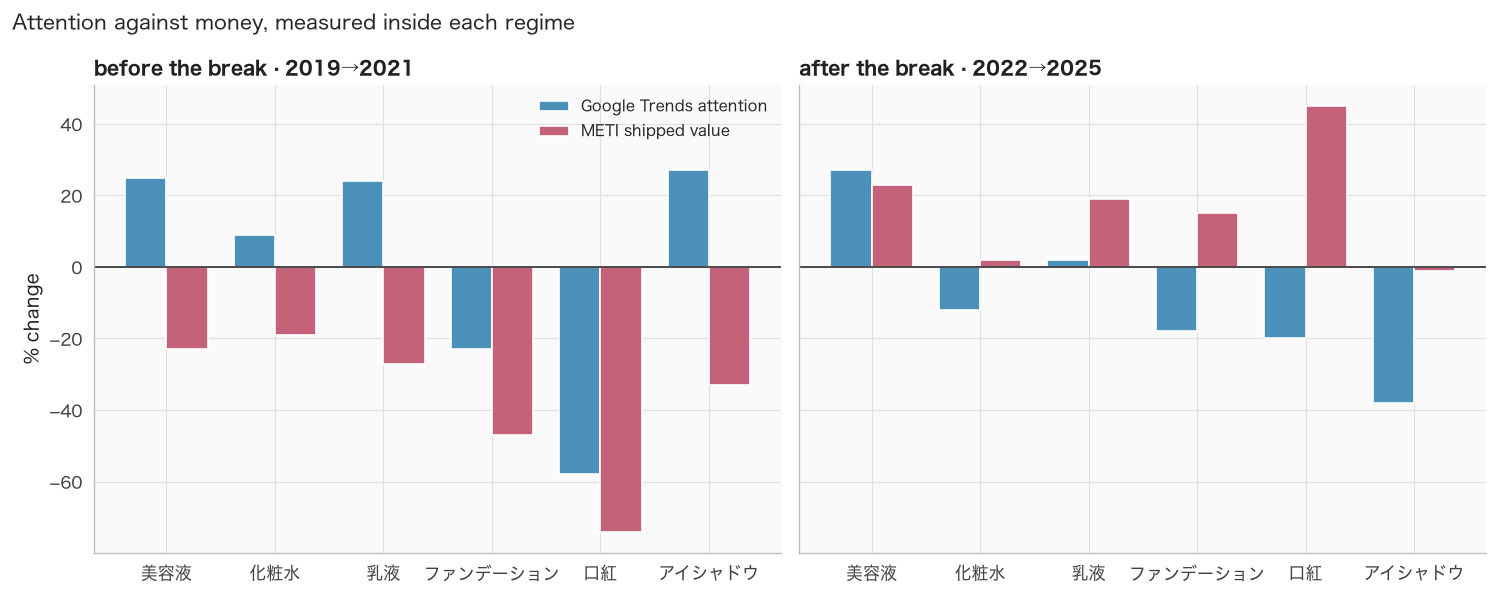

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), sharey=True)
for ax, (lab, y0, y1) in zip(axes, REGIMES):
    d = deltas(y0, y1)
    x = np.arange(len(d)); w = 0.38
    ax.bar(x - w/2, d['attention Δ%'], w, color=C_ATT, label='Google Trends attention')
    ax.bar(x + w/2, d['value Δ%'],     w, color=C_VAL, label='METI shipped value')
    ax.axhline(0, color='#2D2D2D', lw=1)
    ax.set_xticks(x); ax.set_xticklabels(d.index, fontsize=10)
    ax.set_title(f'{lab} the break · {y0}→{y1}', fontsize=11, loc='left')
    ax.set_ylabel('% change' if ax is axes[0] else '')
axes[0].legend(fontsize=9, frameon=False)
fig.suptitle('Attention against money, measured inside each regime', fontsize=12, x=0.005, ha='left')
plt.tight_layout()
plt.show()


---
## 4. The category-level picture

The headline finding in NB05–NB07 is that 「化粧品」 search fell about a third
while 「スキンケア」 held flat. If that reflected demand, shipped value should show
the same shape.

In [8]:
SKIN = ['洗顔クリーム・フォーム','クレンジングクリーム','マッサージ・コールドクリーム',
        'モイスチャークリーム','乳液','化粧水','美容液','パック','男性皮膚用化粧品',
        'その他の皮膚用化粧品']
MAKE = [c for c in ['ファンデーション','おしろい','口紅','リップクリーム','ほほ紅',
                    'アイメークアップ','まゆ墨・まつ毛化粧料','つめ化粧料(除光液を含む)',
                    'その他の仕上用化粧品'] if c in meti.columns]

tot = meti[LEAF].sum(axis=1)
s, k = meti[SKIN].sum(axis=1), meti[MAKE].sum(axis=1)
summary = pd.DataFrame({'all cosmetics 億円': tot.round(0),
                        '皮膚用 skincare': s.round(0),
                        '仕上用 makeup': k.round(0),
                        'skincare:makeup': (s/k).round(2)})
print(summary.to_string())
print(f'''
Trends 「化粧品」   {trend.loc[Y0,"化粧品"]:.1f} → {trend.loc[Y1,"化粧品"]:.1f}  ({100*(trend.loc[Y1,"化粧品"]-trend.loc[Y0,"化粧品"])/trend.loc[Y0,"化粧品"]:+.0f}%)
METI all cosmetics {tot[Y0]:,.0f} → {tot[Y1]:,.0f} 億円  ({100*(tot[Y1]-tot[Y0])/tot[Y0]:+.0f}%)''')

      all cosmetics 億円  皮膚用 skincare  仕上用 makeup  skincare:makeup
year                                                             
2019           17611.0        8876.0      3730.0             2.38
2020           14784.0        7718.0      2457.0             3.14
2021           13529.0        6897.0      2183.0             3.16
2022           12654.0        5685.0      2428.0             2.34
2023           13025.0        5678.0      2703.0             2.10
2024           13745.0        6116.0      2872.0             2.13
2025           13907.0        6293.0      2811.0             2.24

Trends 「化粧品」   85.6 → 57.8  (-32%)
METI all cosmetics 17,611 → 13,907 億円  (-21%)


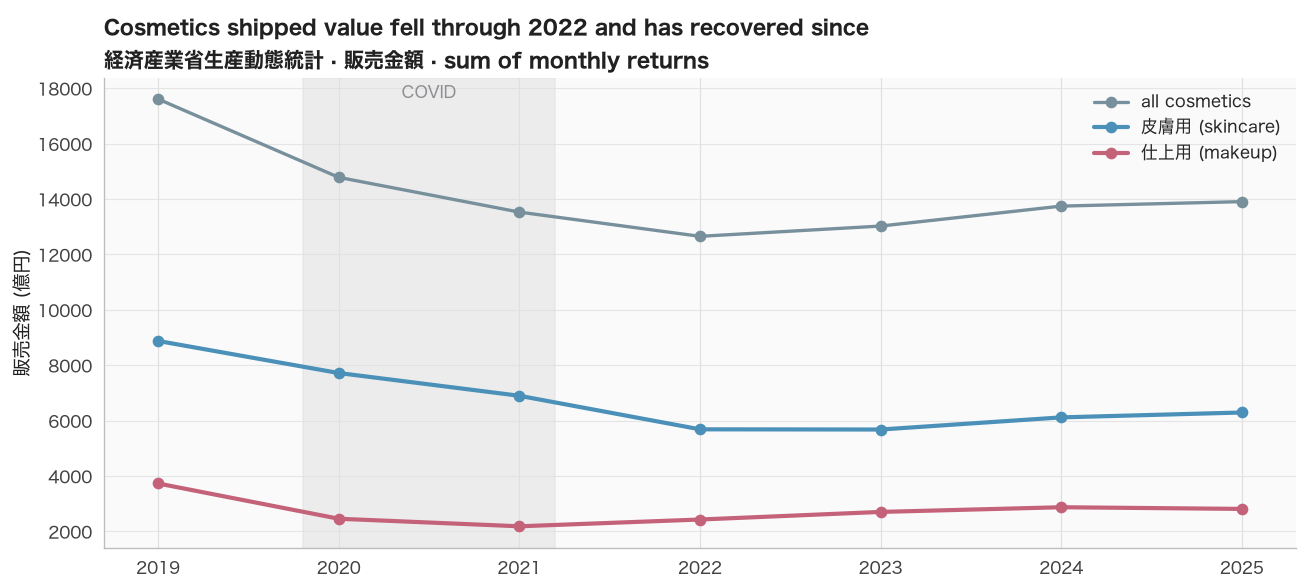

In [9]:
fig, ax = fig_ax(11, 5)
ax.plot(tot.index, tot.values, 'o-', color='#78909C', lw=2, label='all cosmetics')
ax.plot(s.index, s.values, 'o-', color=C_ATT, lw=2.5, label='皮膚用 (skincare)')
ax.plot(k.index, k.values, 'o-', color=C_VAL, lw=2.5, label='仕上用 (makeup)')
ax.axvspan(2019.8, 2021.2, color='#E0E0E0', alpha=.5, zorder=0)
ax.annotate('COVID', (2020.5, ax.get_ylim()[1]*0.96), ha='center', color='#8E8E93', fontsize=10)
ax.set_ylabel('販売金額 (億円)'); ax.set_xlabel('')
ax.set_title('Cosmetics shipped value fell through 2022 and has recovered since\n'
             '経済産業省生産動態統計 · 販売金額 · sum of monthly returns',
             fontsize=12, loc='left')
ax.legend(frameon=False, fontsize=10)
tight(fig)
plt.show()

In [10]:
# The year in progress, against the same months a year earlier.
ytd_y = int(val.year.max()); ytd_m = int(val[val.year == ytd_y].month.max())
same = (val[(val.month > 0) & (val.month <= ytd_m)]
        .groupby(['year','item'])['value'].sum().unstack() / 1e5)
leaf = [c for c in same.columns if not c.endswith('計')]
for name, items in [('皮膚用', SKIN), ('仕上用', MAKE), ('all', leaf)]:
    a, b = same.loc[ytd_y - 1, items].sum(), same.loc[ytd_y, items].sum()
    print(f'{name:4} Jan–{ytd_m} {ytd_y - 1} {a:8,.0f} → {ytd_y} {b:8,.0f} 億円  ({100*(b-a)/a:+.1f}%)')
print('(monthly 確報; revised when the annual table opens)')

皮膚用  Jan–7 2025    3,463 → 2026    3,731 億円  (+7.7%)
仕上用  Jan–7 2025    1,566 → 2026    1,561 億円  (-0.3%)
all  Jan–7 2025    7,886 → 2026    8,202 億円  (+4.0%)
(monthly 確報; revised when the annual table opens)


---
## 4b. The 2022 break

Section 3 gave two incompatible readings of the same skincare lines. This
section establishes that the boundary between them is a discontinuity in the
source, not a change in behaviour, and locates it from the data rather than
assuming it.

Three properties distinguish a reporting break from a demand event: it is
**narrow** (few lines move), it is **a price move larger than the volume move** (2022:
美容液 kg +2% against value −34%; 化粧水 kg −12% against value −36%), and it is **a level shift** (one step, then a new
plateau, rather than a trend).

In [11]:
# 1. Locate it. For each year, how far did 化粧水/美容液/乳液 move against the
#    rest of the market? The break is where that gap is widest.
AFFECTED = ['化粧水', '美容液', '乳液']
others = [c for c in LEAF if c not in AFFECTED]
gaps = {}
for y in range(int(meti.index.min()) + 1, int(meti.index.max()) + 1):
    moved = (meti.loc[y, AFFECTED] / meti.loc[y-1, AFFECTED] - 1).mean()
    rest  = (meti.loc[y, others]   / meti.loc[y-1, others]   - 1).mean()
    gaps[y] = moved - rest
located = min(gaps, key=gaps.get)
print('gap between the three lines and the rest of the market, by year:')
print('  ' + '  '.join(f'{y}: {g:+.0%}' for y, g in gaps.items()))
print(f'-> break located at {located}  (BREAK constant says {BREAK})')

# 2. Narrow? Count the component lines that fell that year.
yoy = (meti.loc[located, LEAF] / meti.loc[located-1, LEAF] - 1)
print(f'\nof {len(LEAF)} component lines, {(yoy < 0).sum()} fell in {located} '
      f'and {(yoy > 0).sum()} rose')
print('the five largest falls:')
print((100 * yoy.nsmallest(5)).round(0).to_string())

# 3. Price, not volume?
vol = (df[(df.measure == '販売数量') & (df.month > 0)]
       .groupby(['year','item'])['value'].sum().unstack() / 1e6)   # kg -> kt
print(f'\n{located} vs {located-1}:')
for it in AFFECTED:
    dv = 100*(meti.loc[located, it]/meti.loc[located-1, it] - 1)
    dq = 100*(vol.loc[located, it]/vol.loc[located-1, it] - 1)
    print(f'  {it:6} value {dv:+5.0f}%   volume {dq:+5.0f}%')


gap between the three lines and the rest of the market, by year:
  2020: +7%  2021: -7%  2022: -40%  2023: -9%  2024: +8%  2025: +1%
-> break located at 2022  (BREAK constant says 2022)

of 33 component lines, 11 fell in 2022 and 22 rose
the five largest falls:
item
化粧水         -36.0
美容液         -34.0
乳液          -27.0
ヘアトリートメント   -21.0
パック         -20.0

2022 vs 2021:
  化粧水    value   -36%   volume   -12%
  美容液    value   -34%   volume    +2%
  乳液     value   -27%   volume    -8%


yen per kg — the three affected lines, then two controls


item     化粧水      美容液       乳液  モイスチャークリーム  ファンデーション
year                                                
2015  7123.0  42069.0  12233.0     28742.0   55584.0
2016  6950.0  36169.0  11309.0     23629.0   45989.0
2017  6815.0  32563.0  10059.0     21703.0   49197.0
2018  6787.0  38074.0  10640.0     15487.0   46811.0
2019  7824.0  42781.0  11148.0     21104.0   44867.0
2020  7550.0  42615.0  11342.0     20034.0   41178.0
2021  7256.0  36853.0   9347.0     21103.0   36585.0
2022  5256.0  23874.0   7426.0     17886.0   38417.0
2023  5168.0  28215.0   8566.0     19292.0   35073.0
2024  5608.0  27184.0   9523.0     18186.0   32641.0
2025  5967.0  28933.0   9049.0     18139.0   32418.0
2026  6686.0  29540.0   9196.0     17664.0   35352.0


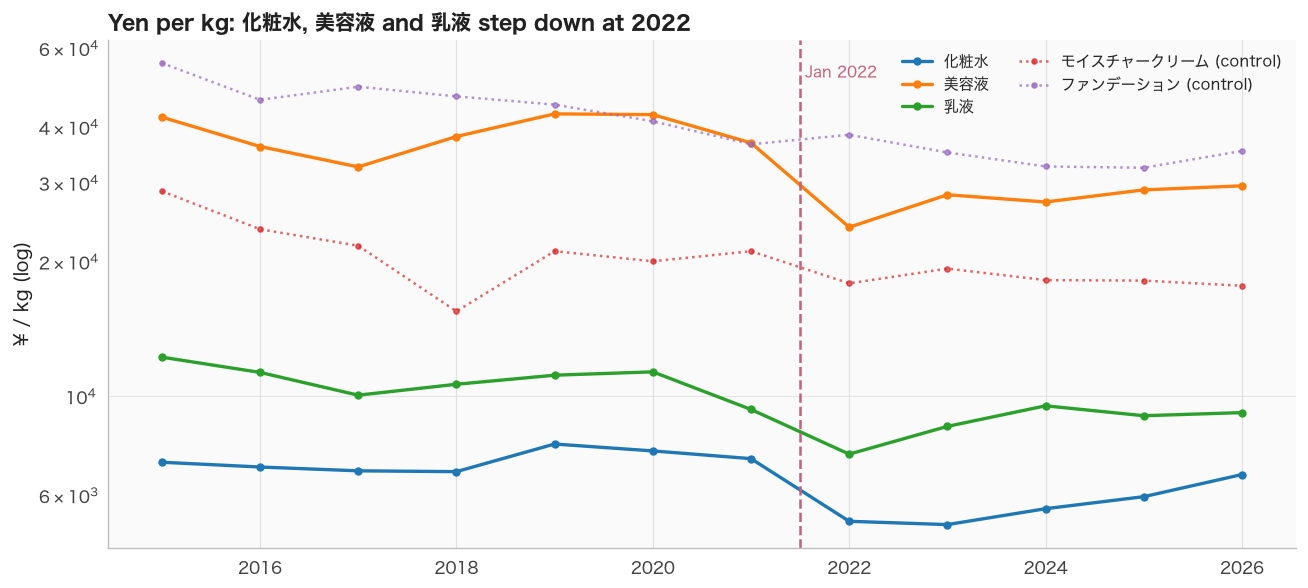

In [12]:
# 4. A level shift, or a trend? Yen per kg back to 2015. Pre-2019 exists only
#    as annual rows, so monthly wins where both exist and the seam is at 2019.
ann = lambda m: (df[(df.measure == m) & (df.month == 0)]
                 .pivot_table(index='year', columns='item', values='value'))
mon = lambda m: (df[(df.measure == m) & (df.month > 0)]
                 .groupby(['year','item'])['value'].sum().unstack())
# combine_first keeps the caller's values and fills the gaps: monthly wins for
# 2019 on, the annual 時系列表 rows supply 2015-2018, and no year mixes the two.
V = mon('販売金額').combine_first(ann('販売金額'))
Q = mon('販売数量').combine_first(ann('販売数量'))
ppk = (V * 1000 / Q)

SHOW = AFFECTED + ['モイスチャークリーム', 'ファンデーション']   # last two are controls
print('yen per kg — the three affected lines, then two controls')
print(ppk[SHOW].round(0).to_string())

fig, ax = fig_ax(11, 5)
for it in AFFECTED:
    ax.plot(ppk.index, ppk[it], marker='o', ms=4, lw=2, label=it)
for it in ['モイスチャークリーム', 'ファンデーション']:
    ax.plot(ppk.index, ppk[it], marker='o', ms=3, lw=1.5, ls=':', alpha=.7, label=f'{it} (control)')
ax.axvline(BREAK - 0.5, color='#C4627A', ls='--', lw=1.5)
ax.text(BREAK - 0.45, ax.get_ylim()[1]*0.95, f'Jan {BREAK}', color='#C4627A', fontsize=9, va='top')
ax.set_yscale('log'); ax.set_ylabel('¥ / kg (log)')
ax.set_title('Yen per kg: 化粧水, 美容液 and 乳液 step down at 2022', fontsize=12, loc='left')
ax.legend(fontsize=9, frameon=False, ncol=2)
plt.tight_layout(); plt.show()


**It is not the correction JCIA footnotes.** The 日本化粧品工業会 shipment page
carries this note:

> 経済産業省生産動態統計の「化粧品」につきましては、一部事業所で誤報告があったため2020年に遡り修正されました。

That restatement is visible in this asset — the 2023 時系列表 disagrees with the
contemporaneous monthly sums for 34 item-years, シャンプー 2021 by +17% and
その他の皮膚用化粧品 by +20%. But **化粧水 and 美容液 are not among the restated
lines**, and the 2022 step survives on the restated vintage. It is a different
event, and the published statistics do not document it.

**Consequence.** No skincare money figure is measured across 2021/2022 anywhere
in this project — not in this notebook, not on the dashboard, not in the README.
Explanation (b) from the earlier draft of this section — import substitution — is
separately dead: section 5 shows imports are roughly an eighth of the market,
peaking at 2,242 億円 in 2023.


---
## 4c. Validating the product-line grouping

Everything above aggregates 33 component lines into 皮膚用 and 仕上用, because
METI stopped publishing the 計 subtotal rows after 2020. A single line in the
wrong group would move every figure, so the partition is pinned twice: against
the subtotal rows that do exist, and against JCIA's published shares.


In [13]:
# Check 1 — reproduce the 計 rows for the two years that have them.
for y in (2019, 2020):
    for grp, name, subtotal in [(SKIN,'皮膚用',' 皮膚用化粧品計'), (MAKE,'仕上用','仕上用化粧品計')]:
        got, want = meti.loc[y, grp].sum(), meti.loc[y, subtotal.strip()]
        flag = 'ok' if abs(got - want) < 0.05 else 'MISMATCH'
        print(f'{y} {name}  computed {got:8,.1f}  published {want:8,.1f}  {flag}')

# Check 2 — JCIA publishes the 2024 shares independently.
tot24 = meti.loc[2024, LEAF].sum()
print(f'\n2024 shipped value {tot24:,.0f} 億円   (JCIA: 13,745)')
for grp, name, jcia in [(SKIN,'皮膚用',44.5), (MAKE,'仕上用',20.9)]:
    print(f'  {name} {100*meti.loc[2024, grp].sum()/tot24:.1f}%   (JCIA: {jcia}%)')
print('\nTwo traps: リップクリーム is 仕上用, ひげそり用・浴用化粧品 is 特殊用途 — neither is skincare.')


2019 皮膚用  computed  8,875.9  published  8,875.9  ok
2019 仕上用  computed  3,729.8  published  3,729.8  ok
2020 皮膚用  computed  7,718.2  published  7,718.2  ok
2020 仕上用  computed  2,456.5  published  2,456.5  ok

2024 shipped value 13,745 億円   (JCIA: 13,745)
  皮膚用 44.5%   (JCIA: 44.5%)
  仕上用 20.9%   (JCIA: 20.9%)

Two traps: リップクリーム is 仕上用, ひげそり用・浴用化粧品 is 特殊用途 — neither is skincare.


---
## 5. What the trade data rules out

Two explanations would reconcile falling domestic shipments with rising skincare
attention without any break. Both are testable, and both fail.

**Import substitution — dead.** If consumption had shifted to imported skincare,
it would appear here as a fall in domestic shipments with no change in
consumption. Imports (HS 3304) are roughly an eighth of the market — 1,667 億円 in
2019, 2,242 億円 at the 2023 peak, 1,688 億円 in 2025 — so they cannot absorb a
decline of this size.

**Exports — dead in the other direction.** Exports peaked in 2021 and fell after,
so subtracting them makes the domestic picture worse, not better.

**The 2019 base being a tourist peak** remains live and is not testable from
these series: purchases made in Japan by visitors sit inside domestic shipments,
and their collapse removes volume without any domestic consumer changing
behaviour. It would depress 2019→2025 comparisons for every category, which is
consistent with what section 4 shows, and it argues for reading the post-2022
regime rather than the full span.


---
## 6. What 家計調査 can and cannot add

The household survey is the other half of caveat 12. It carries per-household
monthly spend, which is immune to the tourist and import problems above — it
measures Japanese households directly.

It cannot answer the main question. **家計調査 has no 美容液 line and no
sunscreen line**; both fall into 他の化粧品 (code 913). The category that moves
most in our attention data is exactly the one household spending does not track.

It does carry 化粧水, 乳液, 化粧クリーム, ファンデーション and 口紅 — enough to
cross-check the makeup half a second time, and to test whether 化粧水's flat
attention matches flat household spend. Left for a follow-up.

---
## Summary

| Claim from NB05–NB07 | Status after official statistics |
|---|---|
| Makeup attention fell and did not recover | **corroborated in money** — ファンデーション −40%, 口紅 −44% shipped value 2019→2025, the fall concentrated in 2019→2021; after 2022 shipped value rose (+15%, +45%) while search kept falling. 口紅 yen per kg also falls at 2022, through kilograms rising 149%, with no step in value |
| Skincare attention held flat while cosmetics fell | **cannot be tested** — the skincare money series breaks at January 2022 and figures measured across it reverse sign when measured inside it |
| Ingredient search rose sharply | **out of scope** — no statistical series tracks ingredient-level demand |
| Skincare:makeup ratio | shipped value runs 2.38 (2019) → 3.16 (2021) → 2.34 (2022) → 2.10 (2023) → 2.13 (2024) → 2.24 (2025): it widens to 2021, falls at the break, reaches 2.10 in 2023 and widens to 2.24 by 2025. The 2019→2025 comparison spans the break |
| Shipments in 2026 | January–July against the same months of 2025: 皮膚用 +7.7%, 仕上用 −0.3%, all cosmetics +4.0% (monthly 確報) |
| Rakuten SKU ratio | **not comparable** — shelf supply on one platform, not domestic shipments across the market. It belongs to the attention layer |

What carries into NB05 and NB07: the makeup finding is stronger than it was, now
resting on search and money together. The skincare finding is an **attention**
finding and must be stated as one — the behavioural check that would confirm or
refute it does not exist in a usable form.

The grouping used throughout is validated in section 4c against both the METI
subtotal rows and JCIA's published shares.